
# Exploratory Data Analysis: Household Power Consumption 📊⚡

This notebook conducts a comprehensive data analysis of the household power consumption dataset. Key focus areas:
1. **Data loading and preprocessing** (missing value handling, temporal conversions).
2. **Global statistics & key extractions**.
3. **Temporal analysis & seasonality** (daily, weekly, monthly behaviors).
4. **Behavioral patterns & correlations** between variables.
5. **Metadata JSON generation**: Findings are directly exported to `eda_infos.json`.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)


## 1. Data Loading and Preprocessing

In [2]:

# Load dataset and treat '?' as NaN
data_path = 'data/household_power_consumption.txt'
print(f"Loading data from {data_path}...")
df = pd.read_csv(data_path, sep=';', na_values=['?', ''], low_memory=False)

# Convert Date and Time
print("Converting Datetime objects...")
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Sort index to be safe
df.sort_index(inplace=True)

df.info()


Loading data from data/household_power_consumption.txt...


Converting Datetime objects...


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


## 2. Missing Values Analysis

In [3]:

missing_stats = df.isna().mean() * 100
missing_count = df.isna().sum()

missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_stats})
print("Missing Value Profile:")
print(missing_df[missing_df['Missing Count'] > 0])

# Since power variables are highly continuous, let's use forward fill (pad) for small gaps or drop them.
# The gaps account for about 1.25%, which is small. We will apply forward fill up to robustly hold temporal properties.
# Optionally, we drop if gaps are consecutive and huge. Forward filling for minimal gaps:
print("Applying forward fill for missing values limit to 10 periods...")
df.fillna(method='ffill', limit=10, inplace=True)
# And the remaining large continuous missing patches can be dropped or imputed by rolling mean.
df.dropna(inplace=True)


Missing Value Profile:
                       Missing Count  Missing %
Global_active_power            25979   1.251844
Global_reactive_power          25979   1.251844
Voltage                        25979   1.251844
Global_intensity               25979   1.251844
Sub_metering_1                 25979   1.251844
Sub_metering_2                 25979   1.251844
Sub_metering_3                 25979   1.251844
Applying forward fill for missing values limit to 10 periods...


## 3. Extracting Key Findings & Saving to `eda_infos.json`

In [4]:

# Basic summary statistics
desc = df.describe().T
desc['skew'] = df.skew()
desc['kurtosis'] = df.kurtosis()

# Correlation Matrix
corr = df.corr()

# Define Key Insights object
eda_info = {
    "dataset_metadata": {
        "start_date": str(df.index.min()),
        "end_date": str(df.index.max()),
        "total_records": len(df),
        "total_days_spanned": (df.index.max() - df.index.min()).days,
        "features_count": len(df.columns),
        "variables": list(df.columns)
    },
    "data_quality": {
        "missing_percentage_before_cleaning": missing_df.to_dict(orient='index')
    },
    "statistics": desc[['mean', 'std', 'min', 'max', '50%', 'skew', 'kurtosis']].to_dict(orient='index'),
    "key_correlations": {
        # Pairs with absolute correlation > 0.6
        "strong_positive_pairs": [
            [col1, col2] for col1 in corr.columns for col2 in corr.columns
            if col1 != col2 and corr.loc[col1, col2] > 0.6 and list(corr.columns).index(col1) < list(corr.columns).index(col2)
        ],
        "strong_negative_pairs": [
            [col1, col2] for col1 in corr.columns for col2 in corr.columns
            if col1 != col2 and corr.loc[col1, col2] < -0.6 and list(corr.columns).index(col1) < list(corr.columns).index(col2)
        ]
    },
    "feature_engineering_recommendations": [
        "Include time-based cyclical features: hour of the day, day of the week, month.",
        "Lag features of 'Global_active_power' are extremely predictable given its strong autocorrelation.",
        "Consider an aggregated 'Sub_metering_remainder' feature: Global_active_power*1000/60 - (Sub_metering_1 + Sub_metering_2 + Sub_metering_3) to represent unmetered background power.",
        "Data has significant right skewness for reactive power and sub-metering; log transformation might be helpful for regression modeling."
    ]
}

# Save JSON
with open('eda_infos.json', 'w') as f:
    json.dump(eda_info, f, indent=4)

print("Saved key findings to `eda_infos.json`. Preview:")
print(json.dumps(eda_info['key_correlations'], indent=4))


Saved key findings to `eda_infos.json`. Preview:
{
    "strong_positive_pairs": [
        [
            "Global_active_power",
            "Global_intensity"
        ],
        [
            "Global_active_power",
            "Sub_metering_3"
        ],
        [
            "Global_intensity",
            "Sub_metering_3"
        ]
    ],
    "strong_negative_pairs": []
}


In [5]:

# Creating remaining energy equation according to data description
# Global_active_power is in kilowatt. Convert to watt-hours corresponding to a minute (x 1000 / 60)
df['Sub_metering_remainder'] = (df['Global_active_power'] * 1000 / 60) - df['Sub_metering_1'] - df['Sub_metering_2'] - df['Sub_metering_3']

# Check negative or faulty values (if any)
invalid_unmetered = (df['Sub_metering_remainder'] < 0).sum()
print(f"Invalid remaining energy records (negative values): {invalid_unmetered}")
if invalid_unmetered > 0:
    df.loc[df['Sub_metering_remainder'] < 0, 'Sub_metering_remainder'] = 0


Invalid remaining energy records (negative values): 1050


## 4. Time Series Trend and Seasonality

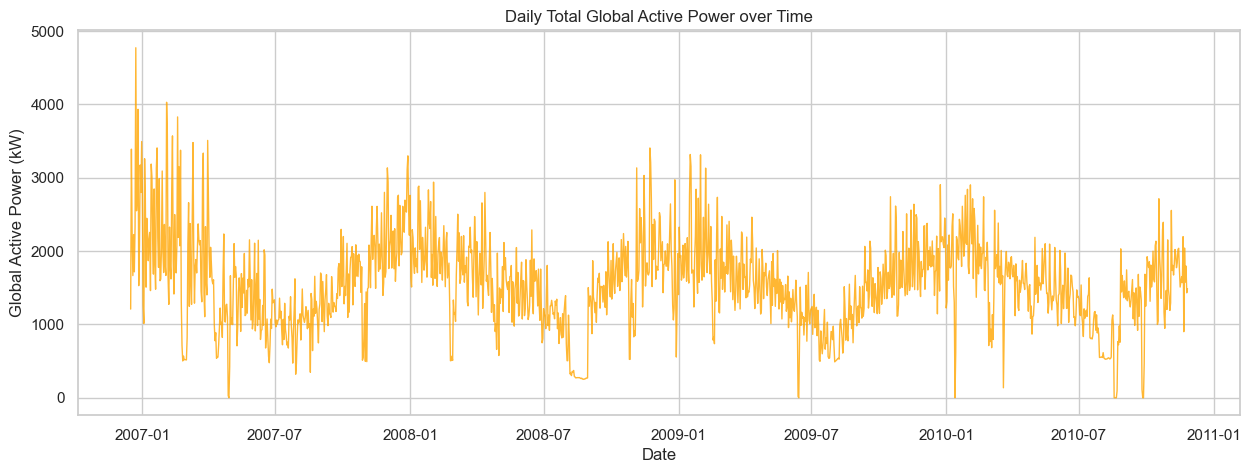

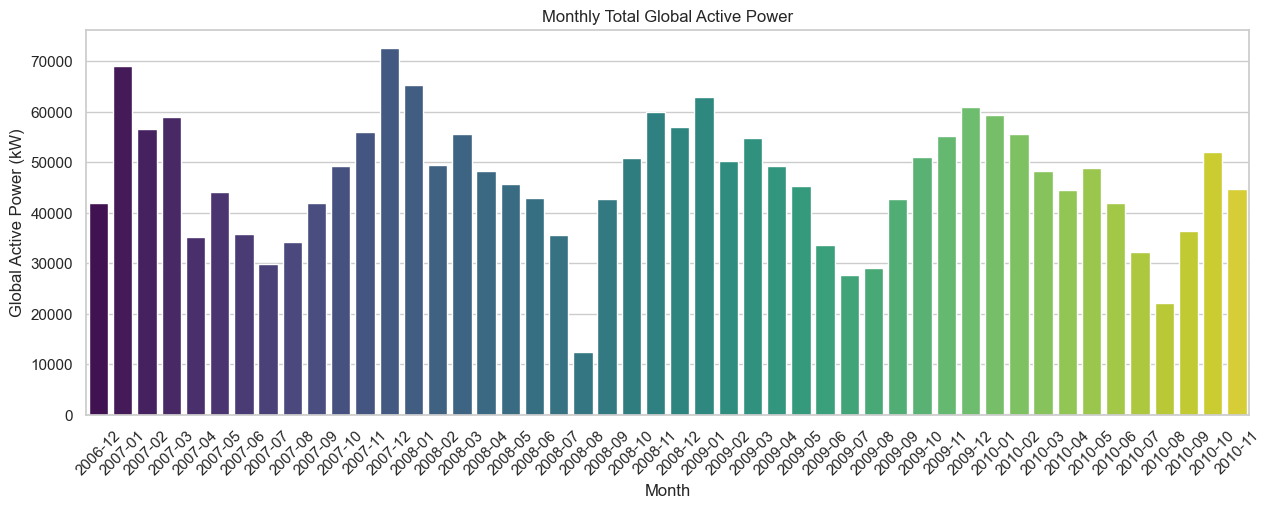

In [6]:

# Resample daily and monthly to visualize trends effectively
df_daily = df.resample('D').sum()
df_monthly = df.resample('M').sum()

# Global Active Power Trend
plt.figure(figsize=(15, 5))
plt.plot(df_daily.index, df_daily['Global_active_power'], color='orange', alpha=0.8, linewidth=1)
plt.title('Daily Total Global Active Power over Time')
plt.ylabel('Global Active Power (kW)')
plt.xlabel('Date')
plt.show()

# Monthly Trend
plt.figure(figsize=(15, 5))
sns.barplot(x=df_monthly.index.strftime('%Y-%m'), y=df_monthly['Global_active_power'], palette='viridis')
plt.title('Monthly Total Global Active Power')
plt.xticks(rotation=45)
plt.ylabel('Global Active Power (kW)')
plt.xlabel('Month')
plt.show()


## 5. Temporal Behavioral Patterns (Daily and Weekly Profiles)

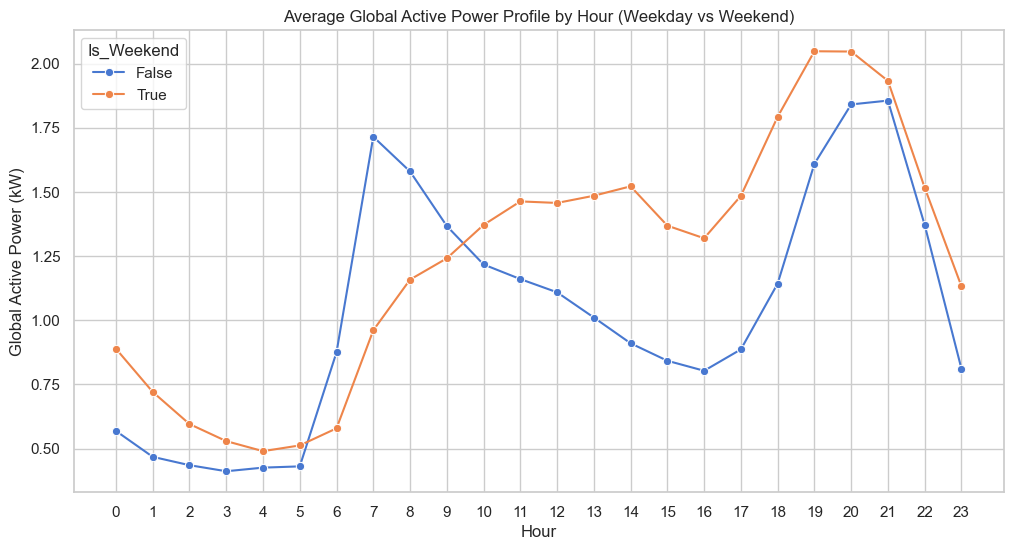

In [7]:

df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Is_Weekend'] = df['DayOfWeek'] >= 5

# Hourly Profile by Weekend vs Weekday
hourly_behavior = df.groupby(['Hour', 'Is_Weekend'])['Global_active_power'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_behavior, x='Hour', y='Global_active_power', hue='Is_Weekend', marker='o')
plt.title('Average Global Active Power Profile by Hour (Weekday vs Weekend)')
plt.xticks(np.arange(0, 24, 1))
plt.ylabel('Global Active Power (kW)')
plt.grid(True)
plt.show()


## 6. Correlation Analysis

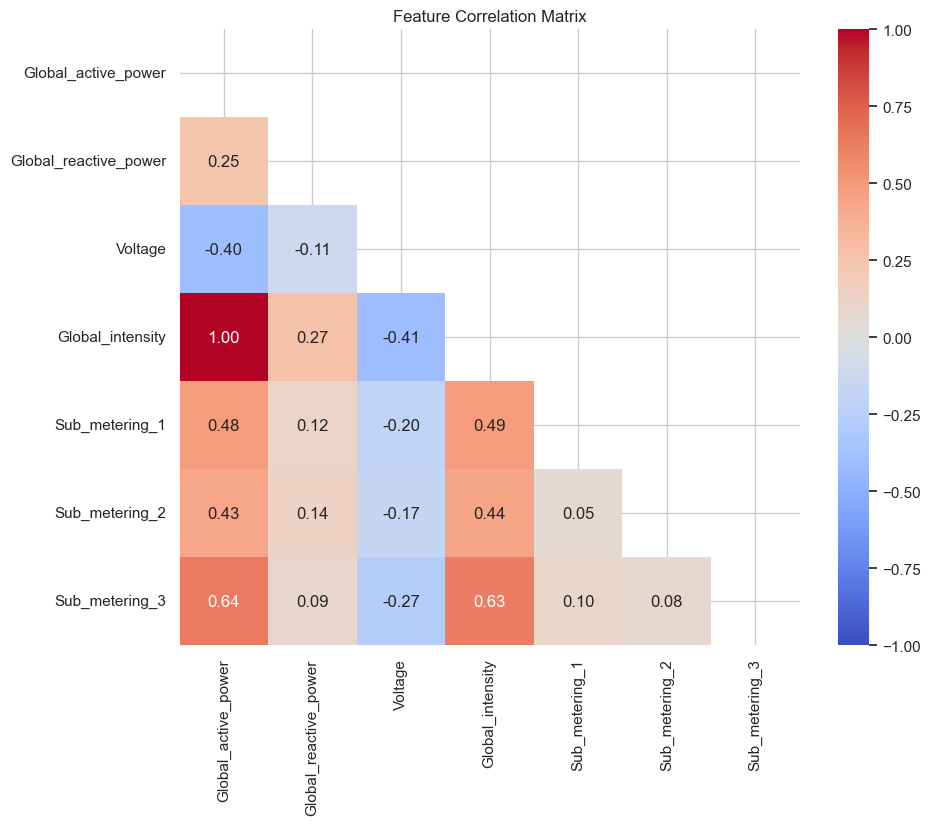

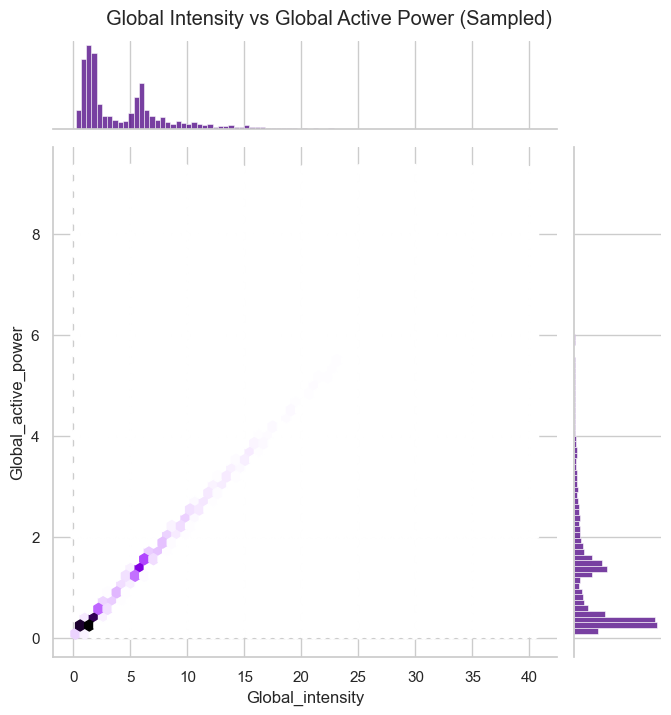

In [8]:

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

# Visualize positive correlation
sns.jointplot(x='Global_intensity', y='Global_active_power', data=df.sample(10000), kind='hex', height=7, color='indigo')
plt.suptitle('Global Intensity vs Global Active Power (Sampled)', y=1.02)
plt.show()
